# NumPy Practice

Let's start with some basic reminders of NumPy and then jump to image manipulation!

In [1]:
import numpy as np

Let's create a simple `numpy array` called `my_array` from a list of lists called `my_list`!

In [2]:
my_list = [[1, 2, 3], [4, 5, 6]]

In [3]:
my_array = np.array([[1, 2, 3], [4, 5, 6]])
my_array

array([[1, 2, 3],
       [4, 5, 6]])

Let's look at the shape of `my_array`

In [4]:
my_array.shape

(2, 3)

You should be seeing a result of `(2, 3)` 

What does this mean? The first element is the number of elements in our first dimension - _remember we had 2 lists in our original list of lists_. The second element is the number of elements in our second dimension - _we had 3 integers inside each of our lists_.

See the images below for an illustration of that concept:

!["NumPy diagram"](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/numpy_axis.png)



We can still turn this `numpy array` back into a `list` of lists. Check your cheatsheet for the method!

In [5]:
my_array.tolist()

[[1, 2, 3], [4, 5, 6]]

In [6]:
type(my_array.tolist())

list

What if you needed to access only the last integer of each list?

In a list we would need a for loop. See an example below:

In [7]:
final_int = []

for lst in my_list:
    final_int.append(lst[-1])

final_int

[3, 6]

With a `numpy array` we can do this without a for loop! 

Give it a go and try to remember which dimension you need to access, shape is important here! Save the results to a variable `last_int_np`

In [8]:
last_int_np = my_array[:,2]
last_int_np

array([3, 6])

How would I add 1 to every number in `my_array`? Save the new array as `my_array_plus`

In [9]:
my_array_plus = my_array + 1
my_array_plus

array([[2, 3, 4],
       [5, 6, 7]])

What if we wanted to add each number in the top row of `my_array_plus` to its matching number in the bottom row?

Save that result to the variable `my_array_reduced`

In [10]:
my_array_reduced = my_array_plus[0 , :] + my_array_plus[1 , :]
my_array_reduced

array([ 7,  9, 11])

What is the shape of `my_array_reduced`?

<details>
<summary>Answer</summary>
The shape is `(3,)`. Our result has only one dimension left, because we summed up the two rows. 

You can also see this when you output the array: there is only one pair of square brackets left.
</details>

What if we wanted to sum up all the numbers of the array horizontally?

We could do something similar like before:

```python
    my_array_plus[:, 0] + my_array_plus[:, 1] + my_array_plus[:, 2]
```

But that is annoying to code. And imagine you have 10 columns, pfff.

Can you think of a faster way?

In [11]:
my_array_plus.sum(axis=1)

array([ 9, 18])

# Manipulating Images with NumPy

NumPy can be tricky to get used to, let's use it to do something practical - like resizing or changing the colour of images - to show direct examples of what is happening!

In [12]:
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

Let's download this image and save it as `cat-hunt.jpg`.

Good practice: use `curl`! It will save your image, or any other kind of data, immediately in the correct place.

In [13]:
!curl https://wagon-public-datasets.s3.amazonaws.com/data-science-images/02-Data-Toolkit/01-Data-Analysis/cat-hunt.jpg > cat-hunt.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 4345k  100 4345k    0     0  14.3M      0 --:--:-- --:--:-- --:--:-- 14.4M


First we will import our image as a `numpy array` and take a look at it using `plt.imshow()`!

In [14]:
cat = np.array(Image.open('cat-hunt.jpg'))

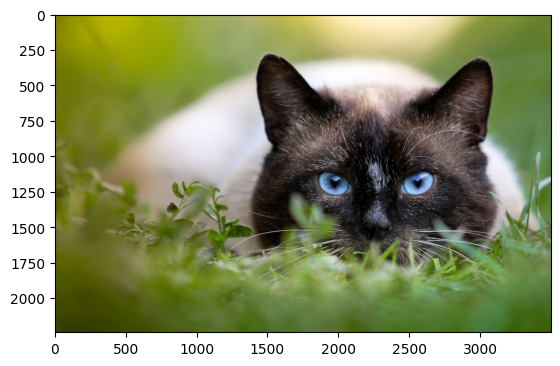

In [15]:
plt.imshow(cat)

## General Investigation

What type is that `cat` variable?

In [16]:
type(cat)

numpy.ndarray

Now that we know what type it is, let's take a look at `cat`
This time we don't want to see the image it would generate, we just want to look directly at what is being stored in the variable

In [17]:
cat

array([[[127, 130,   0],
        [127, 130,   0],
        [127, 130,   1],
        ...,
        [103, 130,  49],
        [102, 131,  49],
        [101, 130,  48]],

       [[128, 131,   0],
        [128, 131,   0],
        [127, 130,   1],
        ...,
        [104, 131,  50],
        [104, 131,  52],
        [102, 129,  48]],

       [[127, 130,   0],
        [127, 130,   0],
        [125, 130,   1],
        ...,
        [104, 128,  50],
        [104, 128,  52],
        [105, 129,  51]],

       ...,

       [[ 59,  68,   1],
        [ 61,  68,   1],
        [ 61,  66,   2],
        ...,
        [ 59,  95,   5],
        [ 60,  95,   5],
        [ 60,  95,   5]],

       [[ 61,  68,   0],
        [ 62,  69,   1],
        [ 61,  66,   0],
        ...,
        [ 57,  93,   3],
        [ 59,  95,   7],
        [ 61,  97,   9]],

       [[ 60,  67,   0],
        [ 60,  67,   0],
        [ 60,  65,   0],
        ...,
        [ 58,  94,   4],
        [ 60,  96,   8],
        [ 62,  98,  10]]

How many dimensions does this numpy array have? Save that result in the variable `cat_dims`

In [18]:
cat_dims = cat.shape
cat_dims

(2242, 3500, 3)

What do these numbers tell us? How large is the photo? What does the last element in that shape represent?

Not sure about that last element? [Here's an article on colour channels](https://www.shutterstock.com/blog/rgb-definition-design-work) that may help to explain! 

<details>
    <summary>Answer</summary>
    The photo is 2242 x 3500 pixels and is made up of RGB (red, green, blue)
</details>

How many individual integers appear inside of this `numpy array`? Save that result in the variable `cat_total`

In [19]:
cat_total = cat.size
cat_total

23541000

How could we get this same number without using the method above?

In [20]:
cat_dims[0] * cat_dims[1] * cat_dims[2]

23541000

## Colour Channels

OK, if we have three colour channels _(RGB = Red, Green, Blue)_ can we look at just one? How would you remove every colour except red from our `cat`? We would need every other colour channel to be changed in some way to make this happen. 

We recommend making a copy of our original `cat`, rather than making changes to the original, otherwise we will have to reload the original image if we want to use it again in this notebook (which we will!)

When you have that red-only `numpy array` assign it to a variable `red_cat`

In [21]:
red_cat = cat.copy() # Make a copy so we don't lose our original cat!
red_cat[:, :, 1:] = 0 # Force every pixel in every channel after the first (red) to be 0
red_cat

array([[[127,   0,   0],
        [127,   0,   0],
        [127,   0,   0],
        ...,
        [103,   0,   0],
        [102,   0,   0],
        [101,   0,   0]],

       [[128,   0,   0],
        [128,   0,   0],
        [127,   0,   0],
        ...,
        [104,   0,   0],
        [104,   0,   0],
        [102,   0,   0]],

       [[127,   0,   0],
        [127,   0,   0],
        [125,   0,   0],
        ...,
        [104,   0,   0],
        [104,   0,   0],
        [105,   0,   0]],

       ...,

       [[ 59,   0,   0],
        [ 61,   0,   0],
        [ 61,   0,   0],
        ...,
        [ 59,   0,   0],
        [ 60,   0,   0],
        [ 60,   0,   0]],

       [[ 61,   0,   0],
        [ 62,   0,   0],
        [ 61,   0,   0],
        ...,
        [ 57,   0,   0],
        [ 59,   0,   0],
        [ 61,   0,   0]],

       [[ 60,   0,   0],
        [ 60,   0,   0],
        [ 60,   0,   0],
        ...,
        [ 58,   0,   0],
        [ 60,   0,   0],
        [ 62,   0,   0]]

What would the image of `red_cat` look like?

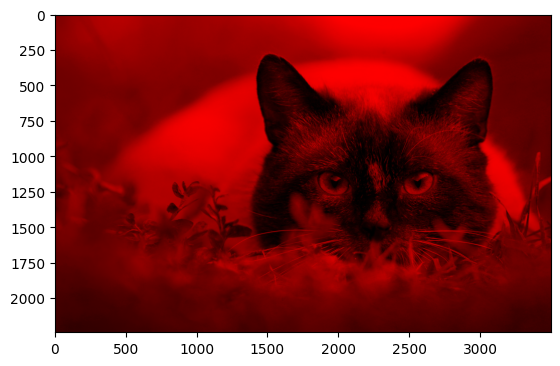

In [22]:
plt.imshow(red_cat)

## Image Resizing

OK, our image has a lot in it, we might want to trim our image down so that it only includes the cat's face! 

The cat's face is between pixels `250` and `1750` in `axis 0` and between `1250` and `3250` in `axis 1`

Make a copy of `cat` called `close_up` that only contains the cat's face using the information above!

In [23]:
close_up = cat[250:1750, 1250:3250, :]

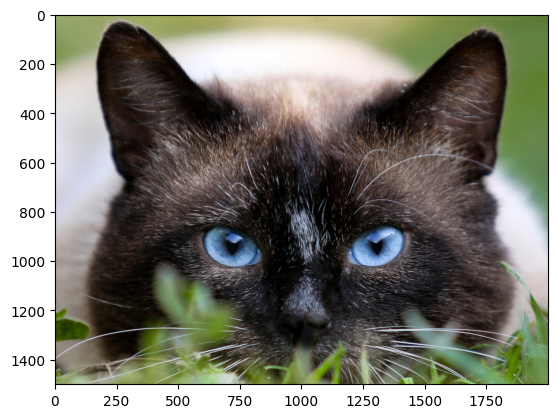

In [24]:
plt.imshow(close_up);

# WOW! You did it! Push your challenge to Kitt!